# Donor-level disease prediction

m3 can predict a **donor's** disease status from their cells, in a leave-one-batch-out
setting: we hold out one batch (B3), hide its donors' labels during training, and
predict them at the end. Runs on the built-in Liu subsample (same settings as the
full-data tutorial; the held-out set is smaller, so numbers may differ a bit).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import m3

OUT = "./tutorial_out_demo/02_patient_prediction"
os.makedirs(OUT, exist_ok=True)

## 1. Load the demo data

In [2]:
data = m3.datasets.liu_demo()
print(data)

Dataset(n_cells=30534, batches=['B1', 'B2', 'B3'], modalities=[rna:1000, adt:192])


/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 2. Build the model with a held-out batch

On top of the columns from the representation-learning tutorial, donor prediction
needs a few more:

- `target_condition`, the condition to predict (here `cond_group`, i.e. disease).
- `donor_key`, the column identifying each donor, so cells are grouped per donor.
- `held_out`, the batch(es) to hold back; these donors' `target_condition` labels
  are hidden during training and predicted at the end.

`model.contract["reference_vocab"]` shows the label set the model learned to predict
(the held-out donors' labels never enter it).

In [3]:
model = m3.M3(
    data,
    condition_keys=["cond_group", "Age_interval"],
    target_condition="cond_group",
    celltype_key="mergedcelltype",
    batch_key="batch",
    donor_key="sample_id",
    held_out=["B3"],
    embedding_dim=30,
)
print("reference vocab:", model.contract["reference_vocab"]["cond_group"])

reference vocab: ['HC', 'Severe']


`.train()` fits the integration model **and** the donor predictor. The
`donor_predictor` dict holds the predictor's training settings: learning rate,
epochs, and how strongly / on what schedule the batch effect is removed. Afterwards
`model.capabilities` shows that `predict_donors` is available.

In [4]:
model.train(
    max_epochs=500,
    donor_predictor={
        "glr": 3e-3, "n_epochs": 120, "adv_max": 10, "adv_warmup": 7,
        "n_disc": 21, "patient_w": 10,
    },
)
print("capabilities:", model.capabilities)

Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'


torch.Size([192, 7163])
Using 'matrix/data'
torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])
Batch counts: {0: 7163, 1: 10789}
Minimum batch size: 7163


Epoch 1, Validation Loss: 4.6703


Epoch 2, Validation Loss: 4.6009


...

...  (494 epochs omitted)  ...


Epoch 498, Validation Loss: 0.4481


Epoch 499, Validation Loss: 0.4480


Epoch 500, Validation Loss: 0.4482


capabilities: {'embedding': True, 'reconstruct': True, 'predict_donors': True}


## 3. Predict the held-out donors

`model.predict_donors()` returns one row per held-out donor: the predicted label and
the probability of each class. We also save it to CSV.

In [5]:
preds = model.predict_donors()
print("query donors:", len(preds))
print(preds.to_string(index=False))
preds.to_csv(os.path.join(OUT, "predictions.csv"), index=False)

query donors: 23
           donor  is_reference predicted_label      prob_HC  prob_Severe
B3_HGR0000051_T0         False          Severe 6.211422e-07     0.999999
B3_HGR0000051_T1         False          Severe 3.821796e-05     0.999962
B3_HGR0000051_T2         False          Severe 1.434713e-04     0.999856
B3_HGR0000051_T3         False          Severe 8.502320e-05     0.999915
B3_HGR0000101_T0         False          Severe 1.689571e-04     0.999831
B3_HGR0000101_T1         False          Severe 1.553886e-06     0.999998
B3_HGR0000101_T3         False          Severe 4.099387e-05     0.999959
B3_HGR0000102_T0         False          Severe 5.886243e-06     0.999994
B3_HGR0000102_T1         False          Severe 1.414257e-06     0.999999
B3_HGR0000134_T0         False          Severe 2.599255e-05     0.999974
B3_HGR0000134_T1         False          Severe 3.862466e-05     0.999961
B3_HGR0000135_T0         False          Severe 3.230921e-06     0.999997
B3_HGR0000135_T1         False    

## 4. Evaluate against the held-out truth

The held-out donors' real labels are in the data (they were only hidden from the
model). We join them back to score accuracy.

In [6]:
# map each donor to its true label, then attach it to the predictions
donor_truth = (data.obs[["sample_id", "cond_group"]].astype(str)
               .drop_duplicates().set_index("sample_id")["cond_group"].to_dict())
preds["true_label"] = preds["donor"].map(donor_truth)
acc = float((preds["predicted_label"] == preds["true_label"]).mean())
print(f"held-out accuracy = {acc:.3f}")

held-out accuracy = 1.000


## 5. Patient-level embedding

`model.donor_embedding()` returns one vector per donor, the donor-level
representation the model actually classifies. We build a small table describing each
donor (reference vs held-out query, true label, correct/wrong) and UMAP the vectors.

In [8]:
import umap

demb = model.donor_embedding()                       # one row per donor
info = model.predict_donors(include_reference=True).set_index("donor").reindex(demb.index)
info["true_label"] = [donor_truth.get(d) for d in demb.index]
info["set"] = np.where(info["is_reference"], "reference", "query")
info["correct"] = np.where(
    info["is_reference"].to_numpy(), "reference",
    np.where(info["predicted_label"].to_numpy() == info["true_label"].to_numpy(),
             "correct", "wrong"))

X = demb.drop(columns=["is_reference"]).to_numpy()
xy = umap.UMAP(n_neighbors=min(15, len(X) - 1), random_state=0).fit_transform(X)
plot_df = info.assign(x=xy[:, 0], y=xy[:, 1])

2026-07-01 12:06:43.258404: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-01 12:06:43.280242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-01 12:06:44.006021: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


The same UMAP, coloured three ways: reference vs query, the true label, and whether
each held-out prediction was correct.

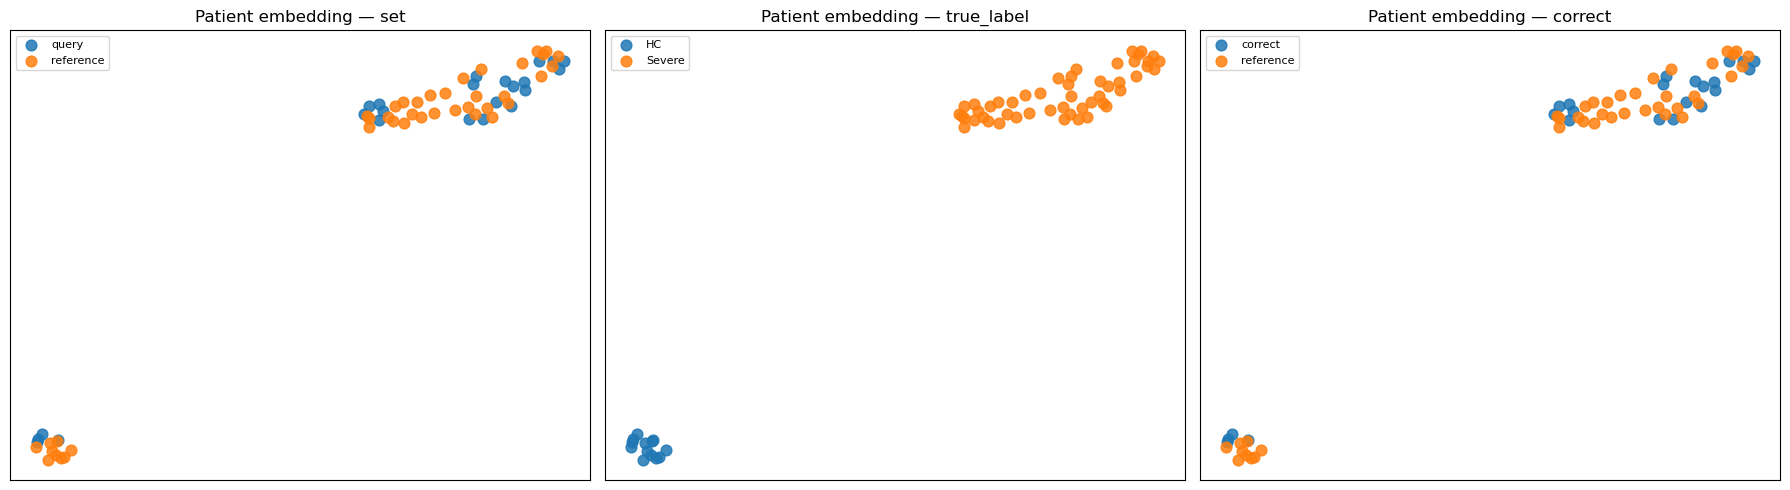

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key in zip(axes, ["set", "true_label", "correct"]):
    for val, sub in plot_df.groupby(key):
        ax.scatter(sub["x"], sub["y"], s=60, alpha=0.85, label=str(val))
    ax.set(title=f"Patient embedding — {key}", xticks=[], yticks=[])
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "patient_embedding_umap.png"), dpi=130, bbox_inches="tight")
plt.show()

## 6. Save the patient embedding

The donor vectors and labels, in the three formats from the representation-learning
tutorial.

In [8]:
import h5py
import anndata as ad

np.save(os.path.join(OUT, "patient_embedding.npy"), X)
with h5py.File(os.path.join(OUT, "patient_embedding.h5"), "w") as f:
    f.create_dataset("data", data=X)
    f.create_dataset("donor_name", data=np.asarray(list(demb.index), dtype="S"))
    f.create_dataset("label", data=np.asarray(info["true_label"].astype(str).to_numpy(), dtype="S"))
    f.create_dataset("is_reference", data=info["is_reference"].to_numpy())
ad.AnnData(X=X, obs=info[["set", "true_label", "correct"]].astype(str)).write_h5ad(
    os.path.join(OUT, "patient_embedding.h5ad"))
print("saved patient embedding -> .npy / .h5 (data+donor_name+label) / .h5ad in", OUT)

... storing 'set' as categorical


... storing 'true_label' as categorical


... storing 'correct' as categorical


saved patient embedding -> .npy / .h5 (data+donor_name+label) / .h5ad in ./tutorial_out_demo/02_patient_prediction


**Done.** Leave-one-batch-out donor prediction, evaluated against the held-out
truth, with a patient-level embedding.